<h1 style="text-align:center; color: #15ab76;">
 Speech Emotion Recognition
</h1>

<h3 style="text-align:center; color: #189681">
Machine learning - Proyecto final
</h3>

<p style="text-align:center; color: #db663b"> 
Primer Semestre 2026<br>
Juana Bertone y Julia Pantin
</p>


### Parte 0 - Definicion
Que es SER?
Que es RAVDESS?
Que modalidades usamos?
Que emociones usamos?
Cual es la tarea?


SER significa "Speech Emotion Recognition", es una tarea de machine learning en la que mediante un audio de voz, queremos predecir la emocion expresada por el actor.
RAVDESS es la base de datos utilizada que contiene grabaciones de 24 actores (12 hombres y 12 mujeres) en distintos formatos(solo audio, audio y video, solo video). En este caso, usamos unicamente los audios, que cuentan con muestras de habla y canto.

Los archivos de RAVDESS tienen el formato MM-VV-EE-II-SS-RR-AA.wav.
MM (modality) que puede ser 01 (Audio-Video), 02 (Video-Only) o 03 (Audio-Only), por lo que todos nuestros archivos van a empezar con 03. CC (Channel) especifica si la muestra corresponde a habla (01 = speech) o canto (02 = song). EE (Emotion) representa la emoción expresada, en este caso usamos 8 que serian neutral, calma, felicidad, tristeza, enojo, miedo, sorpresa y disgusto. II (Intensity) indica la intensidad emocional (01 = normal, 02 = strong). SS (Statement) identifica la frase pronunciada (hay dos opciones), RR (Repetition) indica si se trata de la primera o segunda repetición de la grabación y por ultimo, AA (Actor) identifica al actor que realizó la interpretación (1-24). Los impares correponden a hombres y los pares mujeres.

Es un problema de clasificacion multiclase, y la tarea es poder predecir la emocion expresada mediante el audio.


desp redactar un poco mejor


In [35]:
modality_map = {
    "01": "audio_video",
    "02": "video_only",
    "03": "audio_only"
}#igual este no hace falta porque son todos 03

channel_map = {
    "01": "speech",
    "02": "song"
}

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

intensity_map = {
    "01": "normal",
    "02": "strong"
}

statement_map = {
    "01": "Kids are talking by the door",
    "02": "Dogs are sitting by the door"
}

repetition_map = {
    "01": 1,
    "02": 2
}


### Parte 1 - Construccion de metadata
A partir de los archivos tengo que obtener : file, actor, gender, emotion, intensity, statement, repetition, modality.

-> metadata_df

In [36]:
import os
from pathlib import Path

import pandas as pd

project_root = Path.cwd()
if not (project_root / "raw").exists():
    project_root = project_root.parent

records = []
folders = [
    project_root / "raw" / "Audio_Speech_Actors_01-24",
    project_root / "raw" / "Audio_Song_Actors_01-24",
]

for root_folder in folders:
    for actor_folder in sorted(os.listdir(root_folder)):
        actor_path = root_folder / actor_folder
        if not actor_path.is_dir():
            continue

        for filename in sorted(os.listdir(actor_path)):
            if not filename.endswith(".wav"):
                continue

            file_path = actor_path / filename
            name = filename.replace(".wav", "")
            modality, channel, emotion, intensity, statement, repetition, actor = name.split("-")

            actor = int(actor)
            gender = "female" if actor % 2 == 0 else "male"

            records.append({
                "file": str(file_path),
                "actor": actor,
                "gender": gender,
                "emotion": emotion_map[emotion],
                "intensity": intensity_map[intensity],
                "statement": statement_map[statement],
                "repetition": int(repetition),
                "channel": channel_map[channel]
            })

metadata_df = pd.DataFrame(records)

print("Cantidad de muestras:", len(metadata_df))
metadata_df.head()


Cantidad de muestras: 2452


,file,actor,gender,emotion,intensity,statement,repetition,channel
0,/Users/juliapantin/Documents/GitHub/Proyecto-F...,1,male,neutral,normal,Kids are talking by the door,1,speech
1,/Users/juliapantin/Documents/GitHub/Proyecto-F...,1,male,neutral,normal,Kids are talking by the door,2,speech
2,/Users/juliapantin/Documents/GitHub/Proyecto-F...,1,male,neutral,normal,Dogs are sitting by the door,1,speech
3,/Users/juliapantin/Documents/GitHub/Proyecto-F...,1,male,neutral,normal,Dogs are sitting by the door,2,speech
4,/Users/juliapantin/Documents/GitHub/Proyecto-F...,1,male,calm,normal,Kids are talking by the door,1,speech


In [37]:
# metadata_df contiene solo metadata derivada del nombre del archivo.
# El análisis del contenido acústico se incorpora más adelante en la Parte 2.
print(metadata_df.shape)


(2452, 8)


### Parte 2 - EDA

Antes de definir el split y extraer features, conviene analizar la calidad del metadata, los desbalances del dataset y algunas características básicas del audio. Como la tarea final es predecir la emoción a partir del audio, este EDA busca detectar sesgos y posibles atajos antes del modelado.

2.1 Cantidad de muestras: speech, song y total.

2.2 Emociones: distribución de clases.

2.3 Intensidad: normal vs strong.

2.4 Género: male vs female.

2.5 Actores: cantidad por actor.

2.6 Texto: statement 1 vs statement 2.

2.7 Cruces: emoción con género, intensidad, canal y statement.

2.8 Posibles fuentes de leakage.

Complemento: EDA acústica básica para no quedarnos solo con metadata.


In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wave
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4)

def summarize_counts(series, sort_index=False):
    counts = series.value_counts()
    if sort_index:
        counts = counts.sort_index()
    return pd.DataFrame({
        "count": counts,
        "pct": (counts / len(series) * 100).round(2)
    })

def plot_count_series(series, title, ax, color="#2a9d8f", rotate=0):
    bars = ax.bar(series.index.astype(str), series.values, color=color, edgecolor="black")
    ax.set_title(title)
    ax.set_ylabel("Cantidad")
    ax.tick_params(axis="x", rotation=rotate)
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{int(height)}",
            (bar.get_x() + bar.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points"
        )

def normalized_crosstab(df, row, col):
    return pd.crosstab(df[row], df[col], normalize="index").round(3)

def duration_from_wav(file_path):
    with wave.open(file_path, "rb") as wav_file:
        return wav_file.getnframes() / wav_file.getframerate()

def read_audio_mono(file_path):
    with wave.open(file_path, "rb") as wav_file:
        sample_rate = wav_file.getframerate()
        sample_width = wav_file.getsampwidth()
        n_channels = wav_file.getnchannels()
        n_frames = wav_file.getnframes()
        audio_bytes = wav_file.readframes(n_frames)

    dtype_map = {1: np.int8, 2: np.int16, 4: np.int32}
    if sample_width not in dtype_map:
        raise ValueError(f"Sample width no soportado: {sample_width}")

    audio = np.frombuffer(audio_bytes, dtype=dtype_map[sample_width]).astype(np.float32)
    if n_channels > 1:
        audio = audio.reshape(-1, n_channels).mean(axis=1)
    return sample_rate, audio


#### Chequeos previos de consistencia

Antes de mirar distribuciones, conviene confirmar que el metadata no tenga faltantes, duplicados ni inconsistencias obvias. También agregamos algunos metadatos acústicos mínimos del archivo (`sample_rate`, duración y cantidad de canales) para detectar anomalías tempranas.


In [39]:
audio_headers = []
for file_path in metadata_df["file"]:
    with wave.open(file_path, "rb") as wav_file:
        audio_headers.append({
            "file": file_path,
            "sample_rate": wav_file.getframerate(),
            "audio_channels": wav_file.getnchannels(),
            "duration_sec": wav_file.getnframes() / wav_file.getframerate()
        })

audio_headers_df = pd.DataFrame(audio_headers)
metadata_audio_df = metadata_df.merge(audio_headers_df, on="file", how="left")

quality_summary = pd.DataFrame({
    "metric": [
        "rows",
        "unique_files",
        "duplicated_rows",
        "duplicated_files",
        "actors",
        "missing_values_total",
        "sample_rates_detected",
        "audio_channel_values_detected"
    ],
    "value": [
        len(metadata_audio_df),
        metadata_audio_df["file"].nunique(),
        int(metadata_audio_df.duplicated().sum()),
        int(metadata_audio_df["file"].duplicated().sum()),
        metadata_audio_df["actor"].nunique(),
        int(metadata_audio_df.isna().sum().sum()),
        metadata_audio_df["sample_rate"].nunique(),
        metadata_audio_df["audio_channels"].nunique()
    ]
})

display(quality_summary)

actor_counts = metadata_audio_df["actor"].value_counts().sort_index()
non_standard_actors = actor_counts[actor_counts != actor_counts.mode().iloc[0]].to_frame("n_samples")
print("Actores con cantidad distinta de la moda:")
display(non_standard_actors if not non_standard_actors.empty else pd.DataFrame({"n_samples": []}))

print("Distribución de sample rate:")
display(metadata_audio_df["sample_rate"].value_counts().sort_index().rename("count").to_frame())

print("Distribución de cantidad de canales de audio:")
display(metadata_audio_df["audio_channels"].value_counts().sort_index().rename("count").to_frame())

print("Cobertura actor x channel:")
display(pd.crosstab(metadata_audio_df["actor"], metadata_audio_df["channel"]))

stereo_examples = metadata_audio_df.loc[metadata_audio_df["audio_channels"] != 1, ["file", "actor", "emotion", "channel", "audio_channels"]]
if not stereo_examples.empty:
    print("Archivos no mono detectados:")
    display(stereo_examples)


,metric,value
0,rows,2452
1,unique_files,2452
2,duplicated_rows,0
3,duplicated_files,0
4,actors,24
5,missing_values_total,0
6,sample_rates_detected,1
7,audio_channel_values_detected,2


Actores con cantidad distinta de la moda:


,n_samples
actor,
18,60


Distribución de sample rate:


,count
sample_rate,
48000,2452


...

,count
audio_channels,
1,2446
2,6


Cobertura actor x channel:


channel,song,speech
actor,,
1,44,60
2,44,60
3,44,60
4,44,60
5,44,60
6,44,60
7,44,60
8,44,60
9,44,60


Archivos no mono detectados:


,file,actor,emotion,channel,audio_channels
5,/Users/juliapantin/Documents/GitHub/Proyecto-F...,1,calm,speech,2
55,/Users/juliapantin/Documents/GitHub/Proyecto-F...,1,surprised,speech,2
247,/Users/juliapantin/Documents/GitHub/Proyecto-F...,5,calm,speech,2
1154,/Users/juliapantin/Documents/GitHub/Proyecto-F...,20,happy,speech,2
1177,/Users/juliapantin/Documents/GitHub/Proyecto-F...,20,fearful,speech,2
2408,/Users/juliapantin/Documents/GitHub/Proyecto-F...,24,neutral,song,2


#### 2.1 a 2.6 Distribuciones principales

En esta parte analizamos el balance global del dataset según canal, emoción, intensidad, género, actor y texto. Esto permite detectar desbalances que después afectan tanto el split como la evaluación del modelo.


Cantidad total de muestras: 2452


,count,pct
channel,,
speech,1440,58.73
song,1012,41.27


,count,pct
emotion,,
calm,376,15.33
happy,376,15.33
sad,376,15.33
angry,376,15.33
fearful,376,15.33
disgust,192,7.83
surprised,192,7.83
neutral,188,7.67


,count,pct
intensity,,
normal,1320,53.83
strong,1132,46.17


,count,pct
gender,,
male,1248,50.9
female,1204,49.1


,count,pct
actor,,
1,104,4.24
2,104,4.24
3,104,4.24
4,104,4.24
5,104,4.24
6,104,4.24
7,104,4.24
8,104,4.24
9,104,4.24


,count,pct
statement,,
Kids are talking by the door,1226,50.0
Dogs are sitting by the door,1226,50.0


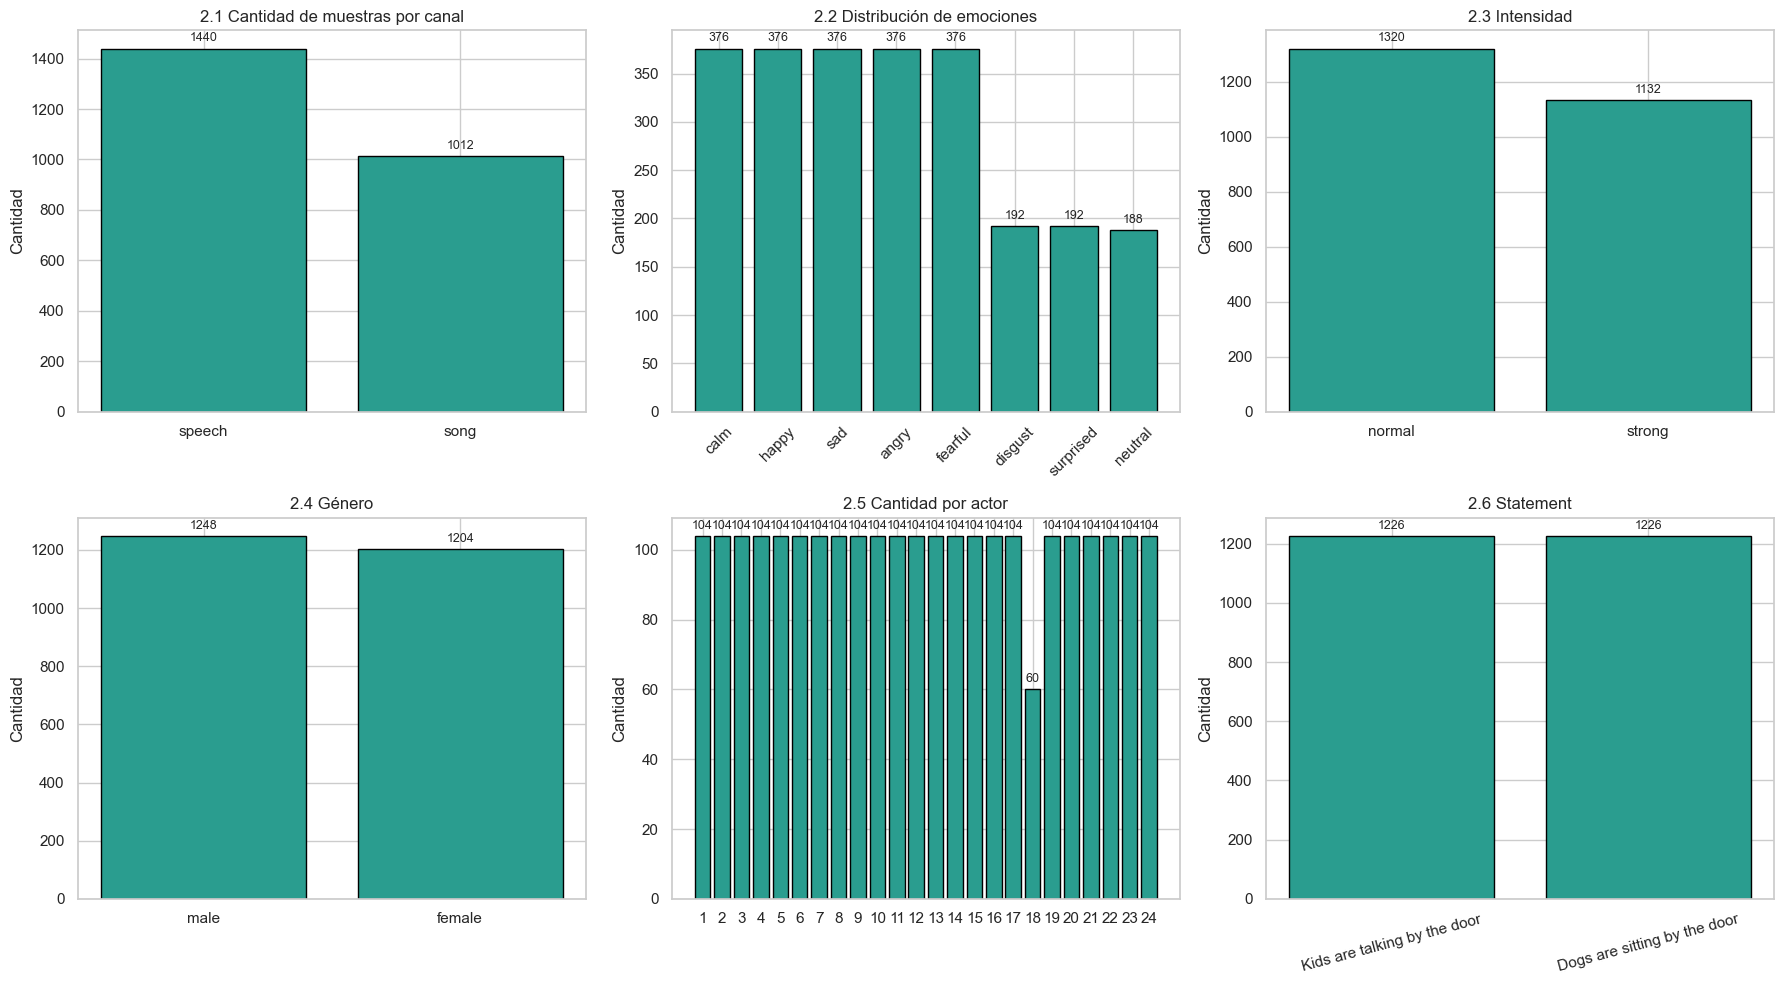

In [40]:
channel_counts = metadata_audio_df["channel"].value_counts()
emotion_counts = metadata_audio_df["emotion"].value_counts()
intensity_counts = metadata_audio_df["intensity"].value_counts()
gender_counts = metadata_audio_df["gender"].value_counts()
actor_counts = metadata_audio_df["actor"].value_counts().sort_index()
statement_counts = metadata_audio_df["statement"].value_counts()

print(f"Cantidad total de muestras: {len(metadata_audio_df)}")
display(summarize_counts(metadata_audio_df["channel"]))
display(summarize_counts(metadata_audio_df["emotion"]))
display(summarize_counts(metadata_audio_df["intensity"]))
display(summarize_counts(metadata_audio_df["gender"]))
display(summarize_counts(metadata_audio_df["actor"], sort_index=True))
display(summarize_counts(metadata_audio_df["statement"]))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_count_series(channel_counts, "2.1 Cantidad de muestras por canal", axes[0, 0])
plot_count_series(emotion_counts, "2.2 Distribución de emociones", axes[0, 1], rotate=45)
plot_count_series(intensity_counts, "2.3 Intensidad", axes[0, 2])
plot_count_series(gender_counts, "2.4 Género", axes[1, 0])
plot_count_series(actor_counts, "2.5 Cantidad por actor", axes[1, 1], rotate=0)
plot_count_series(statement_counts, "2.6 Statement", axes[1, 2], rotate=15)
plt.tight_layout()
plt.show()


#### Lectura de 2.1 a 2.6

- El dataset tiene 2452 muestras en total y está desbalanceado entre canales: hay más ejemplos de `speech` que de `song`.
- La distribución de emociones no es uniforme: `angry`, `calm`, `fearful`, `happy` y `sad` tienen más ejemplos que `neutral`, `disgust` y `surprised`. Esto anticipa que después conviene reportar métricas como `macro F1`, no solo `accuracy`.
- La intensidad también está levemente desbalanceada, pero lo más importante es que su relación con la emoción no es completamente libre; ese punto aparece con más claridad en los cruces.
- El género está casi balanceado entre hombres y mujeres, por lo que no parece haber un sesgo fuerte a simple vista.
- La distribución por actor es casi uniforme, salvo una anomalía clara: el actor 18 tiene muchas menos muestras que el resto. Este hallazgo importa para el diseño del split y para interpretar resultados.
- Los dos `statement` están perfectamente balanceados, lo cual sugiere que el texto no introduce desbalance global por sí solo.


#### 2.7 Cruces entre variables

Los cruces permiten ver si ciertas variables funcionan como proxies parciales de la emoción o si hay combinaciones ausentes en el dataset. Para eso conviene mirar tanto las tablas absolutas como las versiones normalizadas por fila.


gender,female,male
emotion,,
angry,184,192
calm,184,192
disgust,96,96
fearful,184,192
happy,184,192
neutral,92,96
sad,184,192
surprised,96,96


intensity,normal,strong
emotion,,
angry,188,188
calm,188,188
disgust,96,96
fearful,188,188
happy,188,188
neutral,188,0
sad,188,188
surprised,96,96


channel,song,speech
emotion,,
angry,184,192
calm,184,192
disgust,0,192
fearful,184,192
happy,184,192
neutral,92,96
sad,184,192
surprised,0,192


statement,Dogs are sitting by the door,Kids are talking by the door
emotion,,
angry,188,188
calm,188,188
disgust,96,96
fearful,188,188
happy,188,188
neutral,94,94
sad,188,188
surprised,96,96


actor,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
emotion,,,,,,,,,,,,,,,,,,,,,
angry,16,16,16,16,16,16,16,16,16,16,...,16,16,16,8,16,16,16,16,16,16
calm,16,16,16,16,16,16,16,16,16,16,...,16,16,16,8,16,16,16,16,16,16
disgust,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
fearful,16,16,16,16,16,16,16,16,16,16,...,16,16,16,8,16,16,16,16,16,16
happy,16,16,16,16,16,16,16,16,16,16,...,16,16,16,8,16,16,16,16,16,16
neutral,8,8,8,8,8,8,8,8,8,8,...,8,8,8,4,8,8,8,8,8,8
sad,16,16,16,16,16,16,16,16,16,16,...,16,16,16,8,16,16,16,16,16,16
surprised,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8


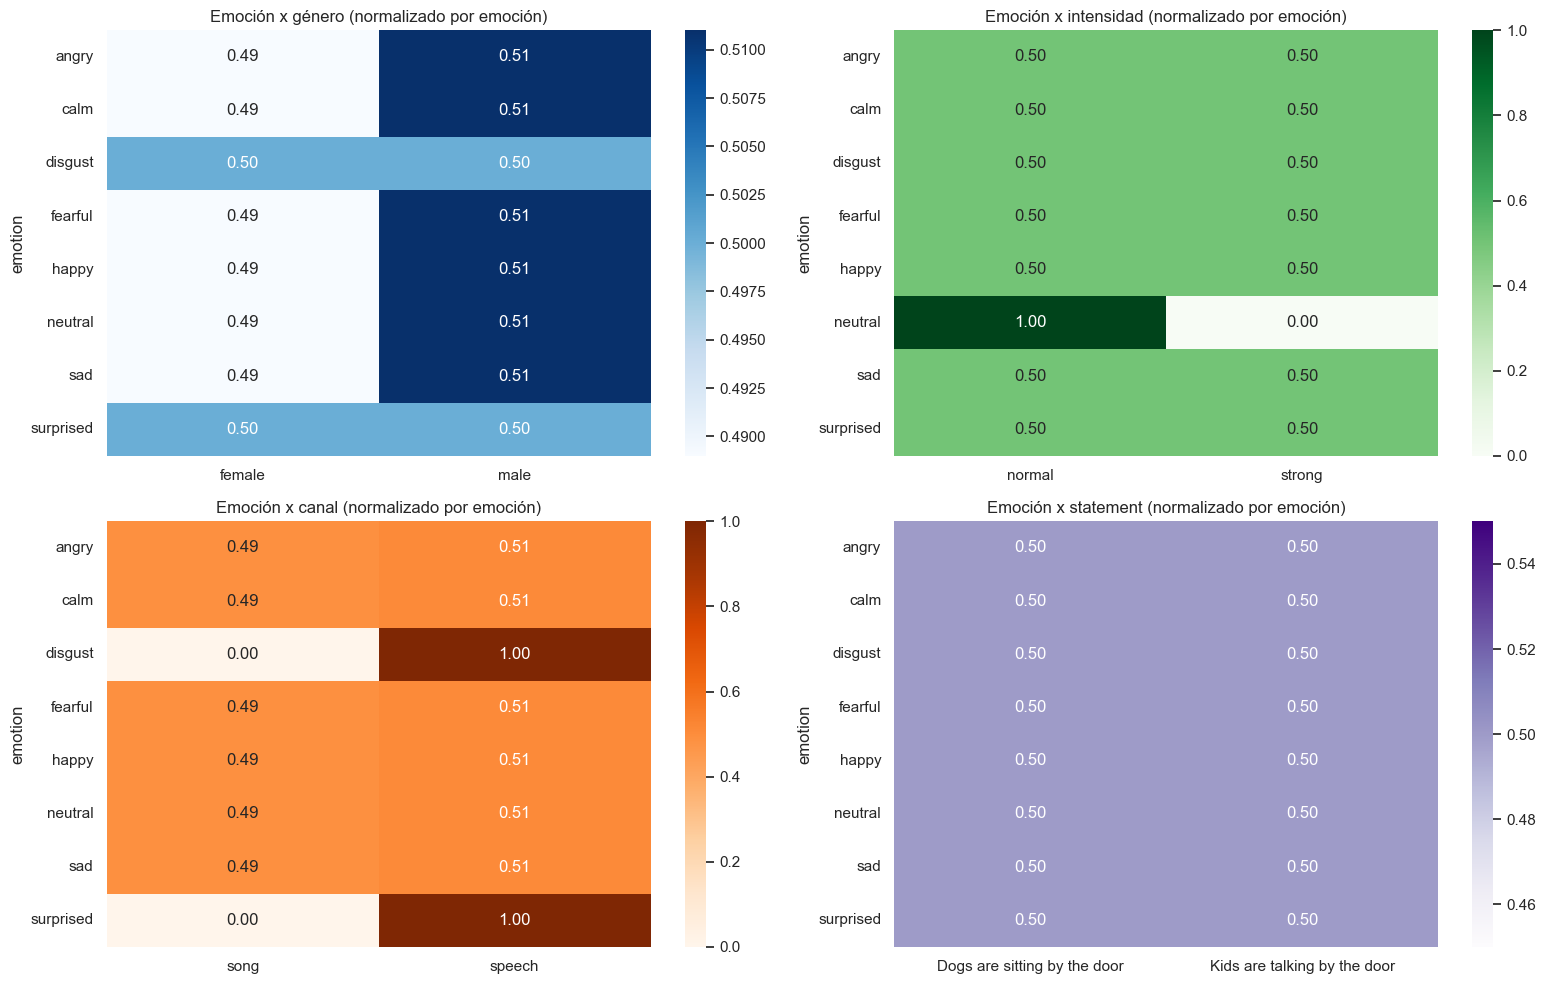

In [41]:
emotion_gender = pd.crosstab(metadata_audio_df["emotion"], metadata_audio_df["gender"])
emotion_intensity = pd.crosstab(metadata_audio_df["emotion"], metadata_audio_df["intensity"])
emotion_channel = pd.crosstab(metadata_audio_df["emotion"], metadata_audio_df["channel"])
emotion_statement = pd.crosstab(metadata_audio_df["emotion"], metadata_audio_df["statement"])
emotion_actor = pd.crosstab(metadata_audio_df["emotion"], metadata_audio_df["actor"])

display(emotion_gender)
display(emotion_intensity)
display(emotion_channel)
display(emotion_statement)
display(emotion_actor)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.heatmap(normalized_crosstab(metadata_audio_df, "emotion", "gender"), annot=True, fmt=".2f", cmap="Blues", ax=axes[0, 0])
axes[0, 0].set_title("Emoción x género (normalizado por emoción)")

sns.heatmap(normalized_crosstab(metadata_audio_df, "emotion", "intensity"), annot=True, fmt=".2f", cmap="Greens", ax=axes[0, 1])
axes[0, 1].set_title("Emoción x intensidad (normalizado por emoción)")

sns.heatmap(normalized_crosstab(metadata_audio_df, "emotion", "channel"), annot=True, fmt=".2f", cmap="Oranges", ax=axes[1, 0])
axes[1, 0].set_title("Emoción x canal (normalizado por emoción)")

sns.heatmap(normalized_crosstab(metadata_audio_df, "emotion", "statement"), annot=True, fmt=".2f", cmap="Purples", ax=axes[1, 1])
axes[1, 1].set_title("Emoción x statement (normalizado por emoción)")

for ax in axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("emotion")

plt.tight_layout()
plt.show()


#### Lectura de 2.7

- `emotion x gender`: la distribución está bastante balanceada, así que género no parece explicar por sí solo las clases.
- `emotion x intensity`: aparece una relación importante, porque `neutral` solo existe con intensidad `normal`. Esto no es leakage directo, pero sí un posible atajo si esa variable se usara como feature.
- `emotion x channel`: es uno de los hallazgos más importantes del EDA. En `song` no aparecen `disgust` ni `surprised`, de modo que el canal reduce artificialmente el espacio de clases posibles.
- `emotion x statement`: los dos textos están balanceados dentro de cada emoción, así que `statement` no parece introducir un sesgo fuerte.
- `emotion x actor`: la mayor parte de los actores tienen cobertura parecida, pero el actor 18 rompe esa uniformidad. Eso refuerza la idea de diseñar el split con cuidado.


#### Complemento: EDA acústica básica

Como el problema final es de audio, no alcanza con analizar solo metadata. También conviene revisar duración, sample rate y algunos ejemplos visuales de la señal para detectar inconsistencias antes de la extracción de features.


,duration_sec
count,2452.000
mean,4.092
std,0.598
min,2.936
25%,3.604
50%,4.004
75%,4.538
max,6.373


,mean,std,min,median,max
channel,,,,,
song,4.649,0.422,3.504,4.605,6.373
speech,3.701,0.337,2.936,3.670,5.272


,mean_duration_sec
emotion,
surprised,3.488
disgust,3.942
fearful,3.959
neutral,3.999
happy,4.080
angry,4.189
sad,4.260
calm,4.404


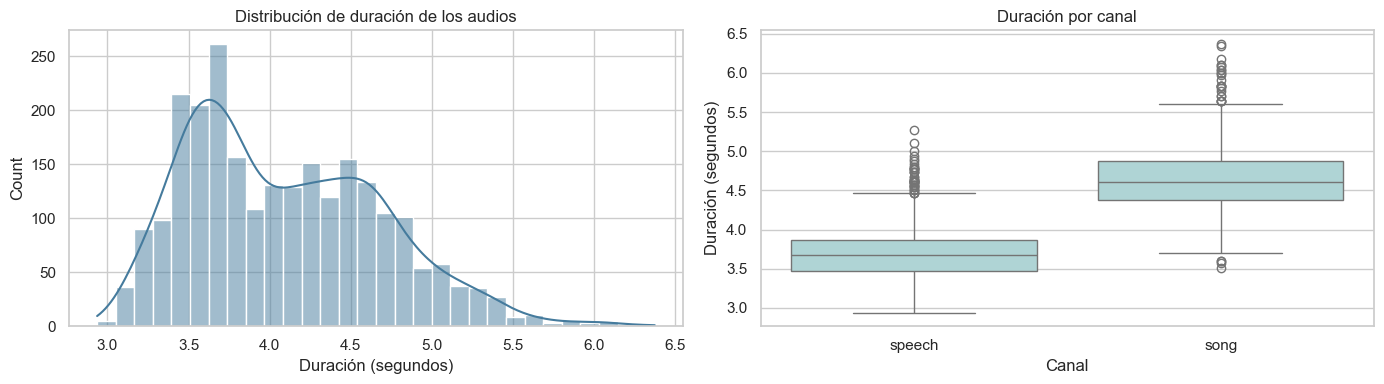

In [42]:
duration_summary = metadata_audio_df["duration_sec"].describe().round(3).to_frame("duration_sec")
duration_by_channel = metadata_audio_df.groupby("channel")["duration_sec"].agg(["mean", "std", "min", "median", "max"]).round(3)
duration_by_emotion = metadata_audio_df.groupby("emotion")["duration_sec"].mean().round(3).sort_values().to_frame("mean_duration_sec")

display(duration_summary)
display(duration_by_channel)
display(duration_by_emotion)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(metadata_audio_df["duration_sec"], bins=30, kde=True, ax=axes[0], color="#457b9d")
axes[0].set_title("Distribución de duración de los audios")
axes[0].set_xlabel("Duración (segundos)")

sns.boxplot(data=metadata_audio_df, x="channel", y="duration_sec", ax=axes[1], color="#a8dadc")
axes[1].set_title("Duración por canal")
axes[1].set_xlabel("Canal")
axes[1].set_ylabel("Duración (segundos)")

plt.tight_layout()
plt.show()


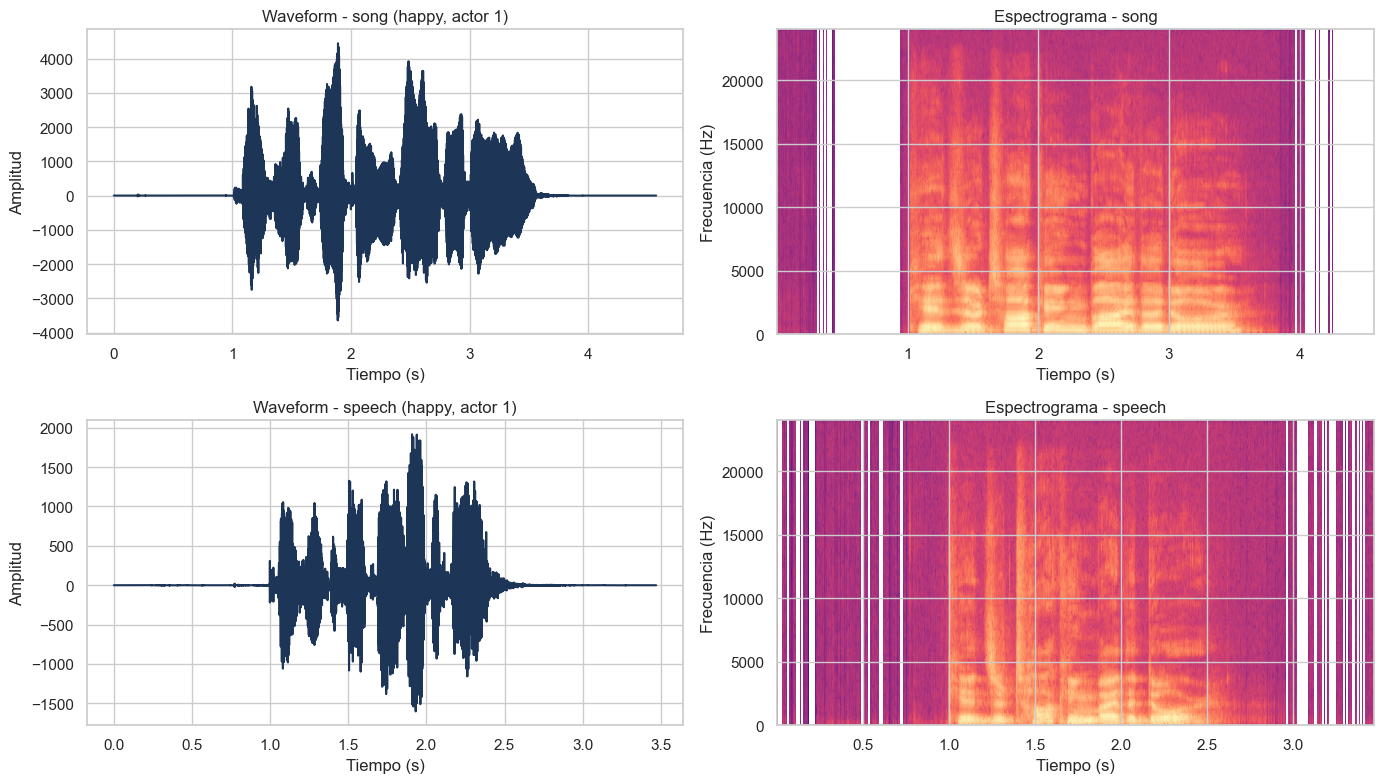

In [43]:
example_mask = (metadata_audio_df["actor"] == 1) & (metadata_audio_df["emotion"] == "happy")
example_files = metadata_audio_df.loc[example_mask].sort_values("channel").drop_duplicates("channel")[["file", "channel", "emotion", "actor"]]

fig, axes = plt.subplots(len(example_files), 2, figsize=(14, 4 * max(len(example_files), 1)))
if len(example_files) == 1:
    axes = np.array([axes])

for row_idx, (_, sample_row) in enumerate(example_files.iterrows()):
    sample_rate, audio = read_audio_mono(sample_row["file"])
    time_axis = np.arange(len(audio)) / sample_rate

    axes[row_idx, 0].plot(time_axis, audio, color="#1d3557")
    axes[row_idx, 0].set_title(f"Waveform - {sample_row['channel']} ({sample_row['emotion']}, actor {sample_row['actor']})")
    axes[row_idx, 0].set_xlabel("Tiempo (s)")
    axes[row_idx, 0].set_ylabel("Amplitud")

    with np.errstate(divide="ignore"):
        axes[row_idx, 1].specgram(audio, Fs=sample_rate, cmap="magma")
    axes[row_idx, 1].set_title(f"Espectrograma - {sample_row['channel']}")
    axes[row_idx, 1].set_xlabel("Tiempo (s)")
    axes[row_idx, 1].set_ylabel("Frecuencia (Hz)")

plt.tight_layout()
plt.show()


#### Lectura del complemento acústico

- Todos los archivos comparten el mismo `sample_rate` (48 kHz), lo cual simplifica la extracción de features y evita una fuente adicional de variabilidad.
- La mayoría de los audios son mono, pero aparecen unos pocos archivos con dos canales. Conviene normalizar esto antes de extraer features para no mezclar representaciones distintas.
- La duración no es constante: los audios de `song` tienden a ser más largos que los de `speech`. Esto puede influir en el valor de algunas features agregadas y conviene tenerlo en cuenta al resumir cada señal.
- Visualizar waveforms y espectrogramas no reemplaza a las features, pero ayuda a confirmar que las muestras de `speech` y `song` tienen comportamientos temporales distintos.


### 2.8 Posibles fuentes de leakage

La principal fuente de leakage potencial es la variable `file`, ya que el nombre del archivo en RAVDESS codifica información como `emotion`, `actor`, `channel`, `intensity`, `statement` y `repetition`. Por lo tanto, esta variable no debe usarse nunca como predictor.

Además, `actor` y `repetition` pueden generar leakage entre train y test si el split se hace por archivo en lugar de agrupar por actor. En ese caso, el modelo podría beneficiarse de escuchar la misma voz en entrenamiento y evaluación, e incluso ejemplos casi duplicados correspondientes a distintas repeticiones de una misma combinación.

Por otro lado, `intensity` y `channel` no representan leakage directo, pero sí pueden actuar como atajos artificiales. En este dataset, la emoción `neutral` solo aparece con intensidad `normal`, y en la modalidad `song` no aparecen algunas emociones como `disgust` y `surprised`. Entonces, usar estas variables como features podría mejorar artificialmente el desempeño sin que el modelo esté aprendiendo realmente la emoción a partir del audio.

En cambio, `statement` no parece ser una fuente relevante de leakage, ya que su distribución se observa balanceada entre clases.

La consecuencia práctica de este EDA es que estas variables sirven para describir el dataset y para diseñar el split, pero no deberían incorporarse como features si la tarea es predecir emoción únicamente a partir del audio.


## Limpieza
Durante la revisión del dataset no se detectaron valores faltantes, duplicados ni archivos evidentemente corruptos, por lo que no fue necesario eliminar muestras. Las únicas particularidades encontradas fueron un actor incompleto (actor 18) y un pequeño número de archivos estéreo. El actor 18 se mantuvo únicamente en train para no afectar validación ni test, y los archivos estéreo se convierten a mono durante la lectura del audio como paso determinístico de preprocesamiento.

### Parte 3 - Diseño del split

El split se define **por actor** para evitar leakage entre entrenamiento y evaluación. De esta forma, la misma voz no puede aparecer en más de un conjunto.

Además, se busca que `validation` y `test` queden balanceados por género y con cobertura completa de `speech` y `song`. El actor 18, que aparece incompleto en el EDA, se deja en `train` para no introducir una anomalía extra en evaluación.

Train: actores `2, 4, 5, 7, 9, 10, 12, 13, 14, 16, 17, 18, 19, 20, 21, 23`

Validation: actores `1, 8, 11, 22`

Test: actores `3, 6, 15, 24`

In [44]:
train_actors = [2, 4, 5, 7, 9, 10, 12, 13, 14, 16, 17, 18, 19, 20, 21, 23]
val_actors = [1, 8, 11, 22]
test_actors = [3, 6, 15, 24]

all_split_actors = set(train_actors) | set(val_actors) | set(test_actors)
assert len(all_split_actors) == 24, "Falta asignar actores al split"
assert set(train_actors).isdisjoint(val_actors)
assert set(train_actors).isdisjoint(test_actors)
assert set(val_actors).isdisjoint(test_actors)

actor_to_split = {actor: "train" for actor in train_actors}
actor_to_split.update({actor: "val" for actor in val_actors})
actor_to_split.update({actor: "test" for actor in test_actors})

metadata_df["split"] = metadata_df["actor"].map(actor_to_split)
metadata_audio_df["split"] = metadata_audio_df["actor"].map(actor_to_split)

split_summary = metadata_audio_df.groupby("split").agg(
    n_samples=("file", "count"),
    n_actors=("actor", "nunique")
).loc[["train", "val", "test"]]

display(split_summary)
display(pd.crosstab(metadata_audio_df["split"], metadata_audio_df["gender"]))
display(pd.crosstab(metadata_audio_df["split"], metadata_audio_df["channel"]))
display(pd.crosstab(metadata_audio_df["split"], metadata_audio_df["emotion"]))


,n_samples,n_actors
split,,
train,1620,16
val,416,4
test,416,4


gender,female,male
split,,
test,208,208
train,788,832
val,208,208


channel,song,speech
split,,
test,176,240
train,660,960
val,176,240


emotion,angry,calm,disgust,fearful,happy,neutral,sad,surprised
split,,,,,,,,
test,64,64,32,64,64,32,64,32
train,248,248,128,248,248,124,248,128
val,64,64,32,64,64,32,64,32


#### A PARTIR DE ACA:

NO MÁS LIMPIEZA

NO MÁS EDA

NO MÁS MODIFICAR SPLITS

### Parte 4 - Feature extraction

Aca aparece : MFCC, Chroma, Spectral Contrast, ZCR y RMS.

Guardar : X_train, X_val, X_test

### Parte 5 - Baseline

Logistic Regression

### Parte 6 - Pipeline 

Definir :

Extracción features

↓

Normalización

↓

Modelo

↓

Evaluación

### Parte 7 - Experimentos

Experimento A : Speech

Experimento B : Song

Experimento C : Speech + Song

Experimento D : Comparacion 

Experimento que aun no sabemos si vas a hacer: Speech -> Song y Song -> Speech

### Parte 8 - Resultados
Matrices de confusion.

Accuracy.

F1.

Analisis de errores.

Emociones mas dificiles.

Emociones mas faciles.

### Parte 9 - Conclusiones